### **Project 01.소셜 유입 유저의 초기 이탈 분석을 통한 랜딩 UX 개선안 도출**

#### **분석 목적**
Google Merchandise Store 사용자 행동 로그를 활용하여
유입 채널별 초기 이탈 차이를 분석하고, </br>
소셜 유입 사용자의 랜딩 이후 행동을 추적하여 주요 이탈 병목과 행동 
특성을 파악한다.

#### **주요 분석 흐름**
1. JSON 로그 데이터 평탄화 및 핵심 행동 변수 선별  
2. 유입 채널 및 랜딩 경로 기준 사용자 그룹화  
3. 채널·랜딩 경로별 행동 및 전환 지표 비교와 통계적 검증  
4. 초기 이탈 완화를 위한 Middle-funnel 랜딩 UX 개선 가설 도출

#### **1. 데이터 로드 및 환경 설정**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

%matplotlib inline

In [3]:
# os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../bigquery-key.json'
# client = bigquery.Client()
# query = " SELECT * FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*` WHERE _TABLE_SUFFIX BETWEEN '20170701' AND '20170731' "
# raw_google_bigquery = client.query(query).to_dataframe()

In [4]:
raw_google_bigquery = pd.read_parquet('./GAS_2/raw_google_bigquery.parquet')

#### **2. 데이터 전처리 및 정제**

In [5]:
drop_cols = ['visitorId', 'userId', 'clientId', 'customDimensions']
raw_google_bigquery = raw_google_bigquery.drop(drop_cols, axis=1)

##### JSON 데이터 평탄화

In [6]:
json_cols = ['totals', 'trafficSource', 'device', 'geoNetwork']

df_json_normalize = []
for col in json_cols:
    json_normalize = pd.json_normalize(raw_google_bigquery[col]).add_prefix(f'{col}_')
    df_json_normalize.append(json_normalize)
    
non_json_cols = [col for col in raw_google_bigquery.columns if col not in json_cols]
non_json_df = raw_google_bigquery[non_json_cols]

df_json = pd.concat(df_json_normalize, axis=1)

df_normalize = pd.concat([df_json, non_json_df], axis=1)

In [7]:
# hits 컬럼 평탄화

df_explode_hits = df_normalize.explode('hits').reset_index(drop=True)
df_hits_details = pd.json_normalize(df_explode_hits['hits'])
df_cleaned = df_explode_hits.drop('hits', axis=1).reset_index(drop=True)
df_cleaned = pd.concat([df_cleaned, df_hits_details], axis=1)

In [8]:
# product 컬럼 평탄화 및 평탄화 데이터 합치기

df_explode_both = df_cleaned.explode('product').explode('promotion').reset_index(drop=True)
df_product_details = pd.json_normalize(df_explode_both['product'].fillna({}), sep='_')
df_promotion_details = pd.json_normalize(df_explode_both['promotion'].fillna({}), sep='_')
df_cleaned = df_explode_both.drop(['product', 'promotion'], axis=1).reset_index(drop=True)
df_cleaned = pd.concat([df_cleaned, df_product_details, df_promotion_details], axis=1)

In [9]:
# 결측치 비율 확인

def check_df_summary(df):
    df_dtypes = df.dtypes
    df_counts = df.count()
    
    df_null_counts = df.isnull().sum()
    df_null_ratio = round((df_null_counts / len(df))*100, 2)
    
    df_info = pd.concat([df_dtypes, df_counts, df_null_counts, df_null_ratio], axis=1)
    df_info.columns = ['Dtypes', 'Counts', 'Null_Counts', 'Null_Ratio']
    
    return df_info.sort_values(by='Null_Ratio', ascending=False)

##### 분석 변수 선별

In [10]:
# 결측치 100%컬럼 제거

na100_cols = ['totals_timeOnScreen', 'totals_screenviews',
       'trafficSource_campaignCode', 'totals_uniqueScreenviews',
       'trafficSource_adwordsClickInfo.creativeId',
       'trafficSource_adwordsClickInfo.criteriaId', 'eventInfo', 'contentInfo',
       'trafficSource_adwordsClickInfo.targetingCriteria',
       'trafficSource_adwordsClickInfo.targetingCriteria.boomUserlistId',
       'device_javaEnabled', 'trafficSource_adwordsClickInfo.customerId',
       'trafficSource_adwordsClickInfo.adGroupId',
       'trafficSource_adwordsClickInfo.campaignId', 'latencyTracking',
       'isSecure', 'social.socialInteractionAction',
       'social.socialInteractionNetwork', 'social.socialInteractionTarget',
       'social.socialInteractions', 'social.uniqueSocialInteractions',
       'promotionActionInfo.promoIsClick', 'transaction',
       'exceptionInfo.description', 'item.productName', 'item.productCategory',
       'item.productSku', 'exceptionInfo.exceptions',
       'exceptionInfo.fatalExceptions', 'item.itemQuantity',
       'item.localItemRevenue', 'item.itemRevenue',
       'contentGroup.contentGroupUniqueViews4',
       'contentGroup.contentGroupUniqueViews5', 'appInfo.version',
       'appInfo.name', 'appInfo.id', 'appInfo.installerId',
       'productRefundAmount', 'item', 'productCouponCode',
       'localProductRefundAmount', 'eventInfo.eventValue',
       'latencyTracking.userTimingVariable', 'latencyTracking.userTimingValue',
       'latencyTracking.userTimingSample', 'latencyTracking.userTimingLabel',
       'latencyTracking.userTimingCategory', 'refund', 'sourcePropertyInfo',
       'appInfo.appInstallerId', 'appInfo.appId', 'promotionActionInfo',
       'publisher', 'appInfo.appVersion', 'appInfo.appName']

df_cleaned = df_cleaned.drop(na100_cols, axis=1)

In [11]:
df_cleaned_check = check_df_summary(df_cleaned)
df_cleaned_check50= df_cleaned_check[df_cleaned_check['Null_Ratio']>=50]
df_cleaned_check50.index

Index(['transaction.transactionCoupon', 'page.searchKeyword',
       'page.searchCategory', 'latencyTracking.domainLookupTime',
       'latencyTracking.redirectionTime',
       'latencyTracking.serverConnectionTime',
       'latencyTracking.domContentLoadedTime',
       'latencyTracking.domInteractiveTime',
       'latencyTracking.domLatencyMetricsSample',
       'latencyTracking.speedMetricsSample',
       'latencyTracking.serverResponseTime', 'latencyTracking.pageLoadTime',
       'latencyTracking.pageDownloadTime', 'latencyTracking.pageLoadSample',
       'transaction.transactionTax', 'transaction.localTransactionTax',
       'contentGroup.contentGroupUniqueViews3', 'localProductRevenue',
       'transaction.transactionRevenue',
       'transaction.localTransactionShipping',
       'transaction.transactionShipping', 'productRevenue',
       'transaction.localTransactionRevenue', 'transaction.affiliation',
       'item.transactionId', 'transaction.transactionId',
       'trafficSourc

In [12]:
# 결측치 50% 이상 컬럼 중 불필요 컬럼 제거

unnecessary_na50_cols = [
'transaction.transactionCoupon', 'page.searchKeyword',
       'page.searchCategory', 'latencyTracking.domainLookupTime',
       'latencyTracking.redirectionTime',
       'latencyTracking.serverConnectionTime',
       'latencyTracking.domContentLoadedTime',
       'latencyTracking.domInteractiveTime',
       'latencyTracking.domLatencyMetricsSample',
       'latencyTracking.speedMetricsSample',
       'latencyTracking.serverResponseTime', 'latencyTracking.pageLoadTime',
       'latencyTracking.pageDownloadTime', 'latencyTracking.pageLoadSample',
       'transaction.transactionTax', 'transaction.localTransactionTax',
       'contentGroup.contentGroupUniqueViews3', 'localProductRevenue',
       'transaction.transactionRevenue',
       'transaction.localTransactionShipping',
       'transaction.transactionShipping', 'productRevenue',
       'transaction.localTransactionRevenue', 'transaction.affiliation',
       'item.transactionId', 'transaction.transactionId',
       'trafficSource_adContent', 'eCommerceAction.option',
       'contentGroup.contentGroupUniqueViews1', 'productQuantity',
       'eventInfo.eventLabel', 'eventInfo.eventAction',
       'eventInfo.eventCategory', 'trafficSource_adwordsClickInfo.isVideoAd',
       'trafficSource_adwordsClickInfo.adNetworkType',
       'trafficSource_adwordsClickInfo.gclId',
       'trafficSource_adwordsClickInfo.page',
       'trafficSource_adwordsClickInfo.slot',
       'totals_transactionRevenue',
       'promotionActionInfo.promoIsView', 'promoPosition', 'promoName',
       'promoId', 'promoCreative', 
       'contentGroup.contentGroupUniqueViews2'
       ]

df_cleaned = df_cleaned.drop(unnecessary_na50_cols, axis=1)

In [13]:
unnecessary_cols = [
 'totals_visits',
 'trafficSource_campaign',
 'trafficSource_isTrueDirect',
 'trafficSource_keyword',
 'trafficSource_medium',
 'trafficSource_source',
 'trafficSource_adwordsClickInfo.criteriaParameters',
 'device_browser',
 'device_browserSize',
 'device_browserVersion',
 'device_deviceCategory',
 'device_flashVersion',
 'device_isMobile',
 'device_language',
 'device_mobileDeviceBranding',
 'device_mobileDeviceInfo',
 'device_mobileDeviceMarketingName',
 'device_mobileDeviceModel',
 'device_mobileInputSelector',
 'device_operatingSystem',
 'device_operatingSystemVersion',
 'device_screenColors',
 'device_screenResolution',
 'geoNetwork_city',
 'geoNetwork_cityId',
 'geoNetwork_continent',
 'geoNetwork_country',
 'geoNetwork_latitude',
 'geoNetwork_longitude',
 'geoNetwork_metro',
 'geoNetwork_networkDomain',
 'geoNetwork_networkLocation',
 'geoNetwork_region',
 'geoNetwork_subContinent',
 'visitNumber',
 'visitStartTime',
 'date',
 'socialEngagementType',
 'customDimensions',
 'customMetrics',
 'customVariables',
 'dataSource',
 'experiment',
 'hour',
 'minute',
 'publisher_infos',
 'time',
 'type',
 'appInfo.exitScreenName',
 'appInfo.landingScreenName',
 'appInfo.screenDepth',
 'appInfo.screenName',
 'contentGroup.contentGroup1',
 'contentGroup.contentGroup2',
 'contentGroup.contentGroup3',
 'contentGroup.contentGroup4',
 'contentGroup.contentGroup5',
 'contentGroup.previousContentGroup1',
 'contentGroup.previousContentGroup2',
 'contentGroup.previousContentGroup3',
 'contentGroup.previousContentGroup4',
 'contentGroup.previousContentGroup5',
 'exceptionInfo.isFatal',
 'item.currencyCode',
 'page.hostname',
 'page.pagePathLevel1',
 'page.pagePathLevel2',
 'page.pagePathLevel3',
 'page.pagePathLevel4',
 'page.pageTitle',
 'social.socialInteractionNetworkAction',
 'social.socialNetwork',
 'transaction.currencyCode',
 'customDimensions',
 'customMetrics',
 'localProductPrice',
 'productBrand',
 'productListName',
 'productListPosition',
 'productPrice',
 'productSKU',
 'productVariant',
 'v2ProductCategory',
 'v2ProductName']

df_cleaned = df_cleaned.drop(unnecessary_cols, axis=1)

In [14]:
fill_0_cols = ['totals_newVisits', 'totals_timeOnSite', 'isEntrance', 'isExit',
                'isClick', 'isImpression']

for col in fill_0_cols:
    df_cleaned[col].fillna(0, inplace=True)

/var/folders/30/zs7bz7k92qb408lhy5d8dvdm0000gn/T/ipykernel_5025/3097667667.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(0, inplace=True)


In [15]:
df_cleaned['totals_pageviews'] = df_cleaned['totals_pageviews'].fillna(1)

In [16]:
bool_na_cols = ['totals_bounces', 'totals_newVisits' , 'isEntrance', 'isExit', 'isClick', 'isImpression']

valid_values = [1, True]

for col in bool_na_cols:
    df_cleaned[col] = df_cleaned[col].fillna(0).isin(valid_values).astype(int)

In [17]:
# 평탄화 과정에서 생긴 상위 컬럼명 제거 

exclude_col = 'eCommerceAction.action_type'

new_columns = []

for col in df_cleaned.columns:
    if col == exclude_col:
        new_columns.append(col)
    elif '_' in col:
        new_columns.append(col.split('_', 1)[1])
    else:
        new_columns.append(col)
        
df_cleaned.columns = new_columns

In [18]:
df_cleaned = df_cleaned.rename(columns={
    'eCommerceAction.action_type' : 'action_type',
    'eCommerceAction.step' : 'step',
    'page.pagePath' : 'pagePath',
    'social.hasSocialSourceReferral' : 'hasSocialReferral'
})

In [19]:
df_raw = df_cleaned[ (df_cleaned['isEntrance']==True) & (df_cleaned['hitNumber']==1) ].reset_index()
df_landing = df_raw.groupby(['fullVisitorId', 'visitId']).first().reset_index()
df_all = df_cleaned.copy()

In [20]:
df_landing = df_landing.drop('index', axis=1)

In [21]:
df_all = df_all.drop_duplicates(subset=['fullVisitorId', 'visitId', 'hitNumber']).copy()

In [24]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    display(df_landing.describe())

,visitId,bounces,hits,newVisits,pageviews,sessionQualityDim,timeOnSite,totalTransactionRevenue,transactions,hitNumber,isEntrance,isExit,step,isClick,isImpression
count,71195.00,71195.00,71195.00,71195.00,71195.00,65246.00,71195.00,995.00,995.00,71195.00,71195.00,71195.00,71195.00,71195.00,71195.00
mean,1500237128.22,0.51,4.47,0.76,3.74,4.20,144.50,140075597.99,1.04,1.00,1.00,0.51,1.00,0.00,0.45
std,759193.24,0.50,8.71,0.43,6.28,12.91,395.74,832429716.06,0.24,0.00,0.00,0.50,0.00,0.00,0.50
min,1498892405.00,0.00,1.00,0.00,1.00,1.00,0.00,3990000.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00
25%,1499593289.00,0.00,1.00,1.00,1.00,1.00,0.00,28045000.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00
50%,1500255889.00,1.00,1.00,1.00,1.00,1.00,0.00,48980000.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00
75%,1500911236.00,1.00,4.00,1.00,4.00,1.00,91.00,99940000.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00
max,1501570783.00,1.00,301.00,1.00,186.00,99.00,11316.00,25249260000.00,4.00,1.00,1.00,1.00,2.00,0.00,1.00


In [25]:
with pd.option_context('display.max_columns', None):    
    display(df_landing[df_landing['hits']>200])

,fullVisitorId,visitId,bounces,hits,newVisits,pageviews,sessionQualityDim,timeOnSite,totalTransactionRevenue,transactions,referralPath,channelGrouping,hitNumber,isEntrance,isExit,isInteraction,referer,action_type,step,pagePath,hasSocialReferral,isClick,isImpression
4063,057693500927581077,1500739622,0,259,0,175.0,88.0,5542.0,NaN,NaN,/,Referral,1,1,0,True,https://mall.googleplex.com/,0,1,/home,No,0,0
9184,1280993661204347450,1500237228,0,204,0,145.0,87.0,4383.0,169400000.0,1.0,/,Referral,1,1,0,True,None,0,1,/google+redesign/apparel/kids/kids+youth,No,0,1
23861,332494308387844831,1498955534,0,251,0,168.0,NaN,5224.0,NaN,NaN,/,Referral,1,1,0,True,None,0,1,/google+redesign/bags/backpacks/home,No,0,1
24112,3361857074092840747,1499453627,0,228,1,139.0,30.0,2142.0,NaN,NaN,/,Referral,1,1,0,True,https://mall.googleplex.com/,0,1,/home,No,0,0
36671,512867189138675160,1500507802,0,234,1,117.0,53.0,400.0,NaN,NaN,None,Direct,1,1,0,True,None,0,1,/store.html,No,0,1
48316,6789528963693848193,1501346674,0,244,0,169.0,85.0,8230.0,NaN,NaN,None,Display,1,1,0,True,https://www.google.com/,0,1,/home,No,0,0
59776,8388931032955052746,1501326835,0,301,0,186.0,28.0,5597.0,NaN,NaN,/,Referral,1,1,0,True,https://mall.googleplex.com/,0,1,/home,No,0,0


#### **3. 탐색적 데이터 분석**

In [22]:
df_landing['bounces'].value_counts(normalize=True).round(2)

bounces
1    0.51
0    0.49
Name: proportion, dtype: float64

In [23]:
bounce_summary = (
    df_landing.groupby('bounces').agg(
        sessions = ('visitId', 'count'),
        hits_mean = ('hits', 'mean'),
        hits_median = ('hits', 'median'),
        pageviews_mean = ('pageviews', 'mean'),
        time_mean=('timeOnSite', 'mean'),
        time_median=('timeOnSite', 'median')
).round(2)
)

bounce_summary

,sessions,hits_mean,hits_median,pageviews_mean,time_mean,time_median
bounces,,,,,,
0,34888,8.07,4.0,6.59,294.87,95.0
1,36307,1.01,1.0,1.00,0.00,0.0


##### 채널별 유입 규모 확인

In [26]:
# Social 유입비중이 네번째로 높고, 이탈률은 65%로 가장 높다

total_sessions = len(df_landing)

df_landing.groupby('channelGrouping').agg(
    bounce_rate = ('bounces', 'mean'),
    session_counts = ('bounces', 'count')
).assign(
    share = lambda x : x['session_counts'] / total_sessions
).round(2).sort_values('session_counts', ascending=False).head(10)

,bounce_rate,session_counts,share
channelGrouping,,,
Organic Search,0.53,37512,0.53
Direct,0.55,12046,0.17
Referral,0.30,9433,0.13
Social,0.65,7725,0.11
Paid Search,0.38,2022,0.03
Affiliates,0.52,1788,0.03
Display,0.40,668,0.01
(Other),1.00,1,0.00


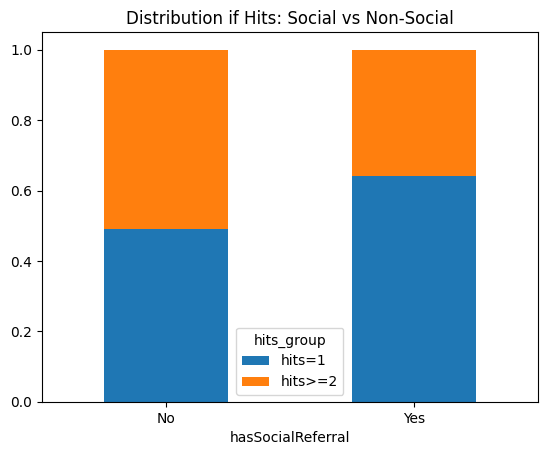

In [27]:
df_landing['hits_group'] = df_landing['hits'].apply(lambda x : 'hits=1' if x==1 else 'hits>=2')

hits_dist = pd.crosstab(df_landing['hasSocialReferral'], df_landing['hits_group'], normalize='index').round(2)

hits_dist.plot(kind='bar', stacked=True);
plt.title('Distribution if Hits: Social vs Non-Social');
plt.xticks(rotation=0);

##### referer 기반 채널 분류

In [79]:
df_landing.groupby('referer').agg(
    bounce_rate = ('bounces', 'mean'),
    session_counts = ('bounces', 'count')
).assign(
    share = lambda x : x['session_counts'] / total_sessions
).round(2).sort_values('session_counts', ascending=False).head(20)

,bounce_rate,session_counts,share
referer,,,
https://www.google.com/,0.39,14312,0.20
https://mall.googleplex.com/,0.13,4479,0.06
https://www.google.co.uk/,0.65,2506,0.04
https://www.google.co.in/,0.61,2428,0.03
https://www.google.ca/,0.38,1317,0.02
http://www.google.com/,0.47,925,0.01
https://www.google.com.au/,0.56,892,0.01
https://analytics.google.com/analytics/web/?utm_source=demoaccount&utm_medium=demoaccount&utm_campaign=demoaccount,0.62,848,0.01
https://www.google.de/,0.64,831,0.01


In [80]:
conditions = [
df_landing['referer'].str.contains('youtube', case=False, na=False),
df_landing['referer'].str.contains('google', case=False, na=False),
df_landing['referer'].str.contains('facebook', case=False, na=False)]

choices = ['Social_Youtube', 'Search_google', 'Social_Facebook']

df_landing['traffic_type'] = np.select(conditions, choices, default='Others')

df_landing.groupby('traffic_type').agg(
    session_counts = ('bounces', 'count'),
    bounces_rate = ('bounces', 'mean')
).sort_values(by='session_counts', ascending=False).round(2)

,session_counts,bounces_rate
traffic_type,,
Search_google,44814,0.48
Others,18909,0.52
Social_Youtube,6634,0.68
Social_Facebook,838,0.62


##### pagePath 기반 페이지 유형 분류

In [90]:
df_landing['pagePath'].unique()

array(['/home', '/asearch.html', '/google+redesign/shop+by+brand/youtube',
       '/google+redesign/apparel/womens/womens+t+shirts',
       '/google+redesign/apparel/women+s/women+s+t+shirts/google+womens+short+sleeve+hero+tee+black.axd',
       '/google+redesign/bags', '/google+redesign/electronics',
       '/google+redesign/shop+by+brand/android',
       '/google+redesign/office/stickers/google+laptop+and+cell+phone+stickers.axd',
       '/google+redesign/apparel/mens/mens+t+shirts',
       '/google+redesign/apparel',
       '/google+redesign/office/notebooks++journals',
       '/google+redesign/electronics/audio/google+g+noise+reducing+bluetooth+headphones.axd',
       '/google+redesign/drinkware/mugs+and+cups', '/signin.html',
       '/google+redesign/office/writing/pen+pencil+highlighter+set.axd',
       '/google+redesign/apparel/kids/kids+youth', '/basket.html',
       '/google+redesign/shop+by+brand/waze+baby+on+board+window+decal.axd',
       '/google+redesign/apparel/mens/mens

In [83]:
df_landing.groupby('pagePath').agg(
    session_counts = ('bounces', 'count'),
    bounce_rate = ('bounces', 'mean')
).assign(
    share = lambda x : x['session_counts'] / len(df_landing)
).round(2).sort_values('session_counts', ascending=False).head(20)

,session_counts,bounce_rate,share
pagePath,,,
/home,34879,0.45,0.49
/google+redesign/shop+by+brand/youtube,17263,0.63,0.24
/google+redesign/apparel/mens/mens+t+shirts,2956,0.47,0.04
/signin.html,1473,0.35,0.02
/google+redesign/apparel,930,0.42,0.01
/google+redesign/bags,915,0.47,0.01
/basket.html,748,0.45,0.01
/google+redesign/shop+by+brand/waze+baby+on+board+window+decal.axd,712,0.65,0.01
/google+redesign/drinkware,655,0.47,0.01


In [58]:
def change_cols(path):
    if path == '/home':
        return 'Home'
    elif 'signin' in path or 'basket' in path:
        return 'System/Conversion'
    elif 'shop+by+brand' in path or '.axd' in path:
        return 'Brand Campaign'
    else:
        return 'Product & Exploration'
    
df_landing['pagePath_group'] = df_landing['pagePath'].apply(change_cols)
df_all['pagePath_group'] = df_all['pagePath'].apply(change_cols)

In [59]:
df_landing['pagePath_group'].value_counts(normalize=True).round(2)

pagePath_group
Home                     0.49
Brand Campaign           0.31
Product & Exploration    0.17
System/Conversion        0.03
Name: proportion, dtype: float64

In [60]:
#0: Unknown (단순 조회 등)
#1: Click through of product lists (상품 목록 클릭)
#2: Product detail views (상품 상세 페이지 조회)
#3: Add product(s) to cart (장바구니 담기)
#4: Remove product(s) from cart (장바구니에서 삭제)
#5: Check out (결제 시작)
#6: Completed purchase (결제 완료)

action_share = pd.crosstab(df_all['hasSocialReferral'], df_all['action_type'], normalize='index').round(3)
action_share

action_type,0,1,2,3,4,5,6
hasSocialReferral,,,,,,,
No,0.720,0.115,0.088,0.038,0.006,0.025,0.007
Yes,0.794,0.098,0.084,0.019,0.002,0.003,0.000


In [61]:
df_all['session_key'] = (
    df_all['fullVisitorId'].astype(str) + '_' +
    df_all['visitId'].astype(str)
)

df_all['is_social'] = df_all['hasSocialReferral'].astype(str).str.contains('Yes', case=False).astype(int)

session_metrics = (
    df_all.groupby('session_key').agg(
        is_social=('is_social', 'max'),
        bounces=('bounces', 'max'),
        total_pageviews=('pageviews', 'max'),
        total_timeOnSite=('timeOnSite', 'max'),
        total_transactions=('transactions', 'max'),
        total_revenue=('totalTransactionRevenue', 'max'),
        max_action=('action_type', 'max'),
        total_clicks=('isClick', 'sum')
    ).reset_index()
)

In [62]:
session_metrics['max_action'] = session_metrics['max_action'].astype(int)

session_metrics.head(2)

,session_key,is_social,bounces,total_pageviews,total_timeOnSite,total_transactions,total_revenue,max_action,total_clicks
0,0000062267706107999_1499645960,0,1,1.0,0.0,NaN,NaN,0,0
1,0000085059828173212_1500505105,0,1,1.0,0.0,NaN,NaN,0,0


In [63]:
session_metrics['cart_abandoned'] = (
    (session_metrics['max_action'] >= 3)
    &
    (session_metrics['total_transactions'] == 0)
).astype(int)

In [64]:
final_report = (session_metrics.groupby('is_social').agg(
        sessions=('session_key','nunique'),
        bounce_rate=('bounces','mean'),
        purchases=('total_transactions','sum'),
        total_revenue=('total_revenue','sum'),
        avg_pageviews=('total_pageviews','mean'),
        avg_timeOnSite=('total_timeOnSite','mean'),
        cart_abandon_rate=('cart_abandoned','mean')
    ).reset_index().round(3)
)

with pd.option_context('display.float_format', '{:.2f}'.format):
    display(final_report)

,is_social,sessions,bounce_rate,purchases,total_revenue,avg_pageviews,avg_timeOnSite,cart_abandon_rate
0,0,63959,0.49,1070.00,160725380000.00,3.95,156.01,0.00
1,1,7749,0.65,2.00,14480000.00,2.25,61.29,0.00


In [65]:
final_report['CVR (%)'] = (
    final_report['purchases'] / final_report['sessions'] * 100
).round(2)

final_report['AOV'] = (final_report['total_revenue'] / 
                       final_report['purchases'].replace(0,np.nan)
).fillna(0)

final_report['Traffic_Source'] = (
    final_report['is_social'].map({
        0:'Non-Social (No)',
        1:'Social (Yes)'
    })
)


display_columns = [
    'Traffic_Source',
    'sessions',
    'bounce_rate',
    'avg_pageviews',
    'avg_timeOnSite',
    'cart_abandon_rate',
    'CVR (%)',
    'AOV'
]

with pd.option_context('display.float_format', '{:.2f}'.format):
    display(final_report[display_columns].round(3))

,Traffic_Source,sessions,bounce_rate,avg_pageviews,avg_timeOnSite,cart_abandon_rate,CVR (%),AOV
0,Non-Social (No),63959,0.49,3.95,156.01,0.00,1.67,150210635.51
1,Social (Yes),7749,0.65,2.25,61.29,0.00,0.03,7240000.00


#### **4. 통계적 검증**

In [66]:
df_social = df_landing[
    df_landing['hasSocialReferral'].fillna('No').astype(str)
    .str.contains('Yes', case=False)
].copy()

In [67]:
def assign_ab_group(page_group):
    if page_group == 'Home':
        return 'A'
    
    elif page_group in ['System/Conversion', 'Brand Campaign']:
        return 'B'

    else:
        return 'Exclude'

df_social['ab_group'] = (
    df_social['pagePath_group'].apply(assign_ab_group)
)

In [68]:
df_test = df_social[
    df_social['ab_group'] != 'Exclude'
].copy()

df_test['ab_group'].value_counts()

ab_group
B    5966
A    1608
Name: count, dtype: int64

In [69]:
contingency = pd.crosstab(
    df_test['ab_group'],
    df_test['bounces']
)

contingency

bounces,0,1
ab_group,,
A,811,797
B,1824,4142


In [70]:
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

contigency = pd.crosstab(df_test['ab_group'], df_test['bounces'])

chi2, p_bounces, _, _ = chi2_contingency(contigency)
p_report = f'{p_bounces:.4f}' if p_bounces > 0.001 else 'p < 0.001'
print(f'chi2 : {chi2:.4f}', f'p_bounce : {p_report}')

chi2 : 219.3796 p_bounce : p < 0.001


In [72]:
A = df_test[df_test['ab_group']=='A']['timeOnSite']
B = df_test[df_test['ab_group']=='B']['timeOnSite']

stat, p_time = mannwhitneyu(A, B)
p_report = f'{p_time:.4f}' if p_bounces > 0.001 else 'p < 0.001'
print(f'stat : {stat}', f'p_time : {p_report}')

stat : 5673116.5 p_time : p < 0.001
